In [1]:
import warnings
warnings.filterwarnings("ignore")

### Importing the libraries

In [2]:
import sys
print(sys.executable)

/Users/macbook/Documents/Code/Machine-Learning-Projects/tf-env/bin/python


In [3]:
# basic + dates 
import numpy as np
import pandas as pd
from datetime import datetime

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
%matplotlib inline

# statistics
from statsmodels.distributions.empirical_distribution import ECDF

# time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# # prophet by Facebook
# from fbprophet import Prophet

### Geting the Data

In [4]:
train  = pd.read_csv("./dataset/train.csv")
store    = pd.read_csv("./dataset/store.csv")
test      = pd.read_csv("./dataset/test.csv")


train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
train.shape, store.shape, test.shape

((1017209, 9), (1115, 10), (41088, 8))

In [6]:
#check for missing values and data types
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [7]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [8]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
#filling in the missing value in competition distance with -1
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(-1, inplace=True)


In [10]:
train = pd.merge(train, store, on='Store')

In [13]:
# #feature engineering - adding new features day, month, year, day of week, week of year, is weekend
# train['Month'] = train['Date'].dt.month
# train['Year'] = train['Date'].dt.year


In [14]:
#feature engineering - hot encoding categorical variables
store = pd.get_dummies(store, columns=['StoreType', 'Assortment'], drop_first=True)

### Checking Data before going to the next step

In [15]:
#all data types should be numeric for modelin 
train.shape
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [16]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [34]:
#fixing te Jupyter Notebook cell memory problem by saving the data to a CSV file

# 1. Reload the original data to clear the notebook memory
train = pd.read_csv('./dataset/train.csv')
store = pd.read_csv('./dataset/store.csv')

# 2. Clean and encode the store data
store['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
store['CompetitionOpenSinceYear'].fillna(0, inplace=True)
store = pd.get_dummies(store, columns=['StoreType', 'Assortment'], drop_first=True)

# 3. Process the dates in the train data
train['Date'] = pd.to_datetime(train['Date'], format='%Y-%m-%d')
train['Month'] = train['Date'].dt.month
train['Year'] = train['Date'].dt.year
train['Day'] = train['Date'].dt.day

# --- NEW FEATURE ENGINEERING GOES HERE ---
train['Beginning_of_Month'] = (train['Day'] <= 5).astype(int)

# 4. Do ONE final merge
train = pd.merge(train, store, on='Store')

In [35]:
#check the train data shape and info
train.shape
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 25 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   Month                      1017209 non-null  int32         
 10  Year                       1017209 non-null  int32         
 11  Day                        1017209 non-null  int

In [36]:
#check if there's any str data type left in the train data
train.select_dtypes(include=['object', 'string']).columns

Index(['StateHoliday', 'PromoInterval'], dtype='str')

In [37]:
#do one-hot encoding for the 'StateHoliday' and 'PromoInterval' columns
train = pd.get_dummies(train, columns=['StateHoliday', 'PromoInterval'], drop_first=True)

In [38]:
train.select_dtypes(include=['object', 'string']).columns

Index([], dtype='str')

#### Now the data is ready

### Modeling Prepraion

In [39]:
#defining the features and target variable

# 1. Filter out closed days
train = train[train['Open'] == 1]

# 2. Filter out days with $0 sales anomalies
train = train[train['Sales'] > 0]

# 3. Extract the target (answers) from the filtered data
y = train['Sales']

# 4. Drop the target and unavailable info to create features (clues)
X = train.drop(['Date', 'Sales', 'Customers', 'Open'], axis=1)


In [40]:
X.shape, y.shape

((844338, 25), (844338,))

In [41]:
#making test train sets
from sklearn.model_selection import train_test_split

#setting a specific random state ensures that if you run the cell again, it shuffles the data the exact same way
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
import xgboost as xgb
model = xgb.XGBRegressor(max_depth=10)

In [48]:
model.fit(X_train, y_train)

#in this single line, the actual ML happens. The XGBoost algo looks at all the clues (X_train) and figures out complex mathematical rules that lead to the actual sales numbers (y_train). The model is now ready to make predictions on the test set.

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [49]:
#train our model on the training set
predictions = model.predict(X_test)

#the predictions variable holds a list of what the model thinks the sales numbers should be for each row in the test set. 

### Evaluation Metric: Root Mean Squar Percentage Error (RMSPE)

In [50]:
import numpy as np
#there's no built-in funtion for RMSPE so we write the function ourselves
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))


score = rmspe(y_test, predictions)
print(f'RMSPE: {score:.4f}')

RMSPE: 0.1294


Now we have our baseline. This score means that our model's prediction is ~19% off from the actual sales. Now we have to optimize our model.
The are two main ways for lowering down this score:
1. Hyperparameter Tuning: Tweaking the internal settings of the XGBoost algorithm.
2. Feature Engineering: Creating entirely new clues (features) from the data we already have.

To optimize my model's score, i used this line of code:

train['Beginning_of_Month'] = (train['Day'] <= 5).astype(int)

but the final score didn't change so apparently, the XGBoost had already considered this while it was doing all the calculation so what i'm gonna do now is I will do ** feature importance ** which allows us to peek inside the model's "brain" to see if our model actually used the "Beginning_of_Month" feature or not

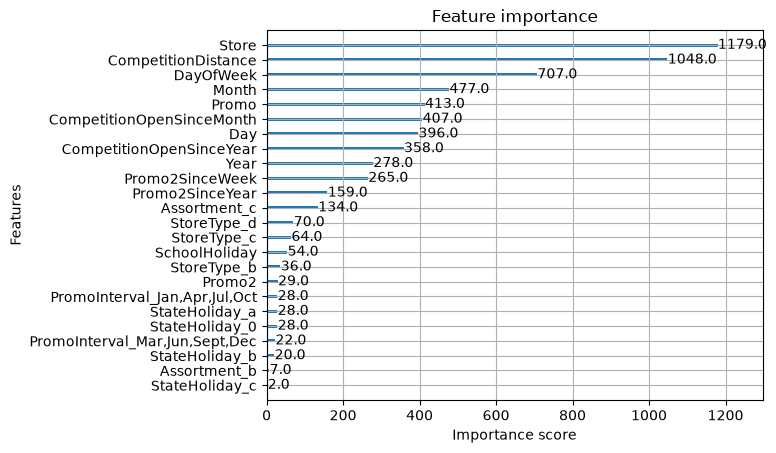

In [46]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot the features based on how often the model used them
plot_importance(model)
plt.show()

## Visualizing The Results

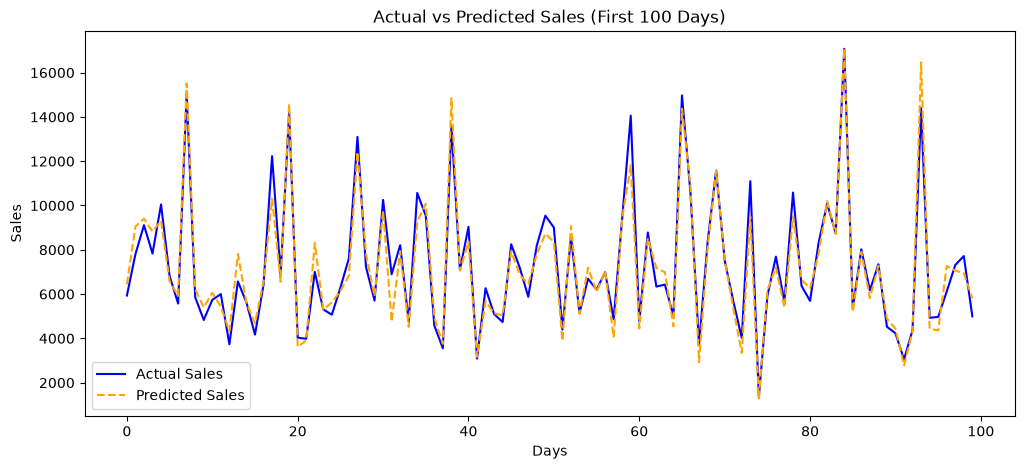

In [51]:
import matplotlib.pyplot as plt

# Make the graph wide enough to see clearly
plt.figure(figsize=(12, 5))

# Plot the real sales in blue (we use .values to reset the index so it lines up perfectly)
plt.plot(y_test[:100].values, label='Actual Sales', color='blue')

# Plot our model's predictions in orange
plt.plot(predictions[:100], label='Predicted Sales', color='orange', linestyle='--')

# Add labels and a legend so we know what we are looking at
plt.title('Actual vs Predicted Sales (First 100 Days)')
plt.ylabel('Sales')
plt.xlabel('Days')
plt.legend()

plt.show()

*A note for myself*

To prove the model isn't overfitting, we need to compare its score on the testing data to its score on the training data. If the training error is super close to 0%, but the testing error is 12.9%, that huge gap means the model memorized the past and is failing to generalize. If the two scores are close to each other, the model is healthy!

In [53]:
predictions = model.predict(X_train)
score = rmspe(y_train, predictions)
print(f'RMSPE: {score:.4f}')

RMSPE: 0.1752
